<a href="https://colab.research.google.com/github/lohaniSatwik/steam-games-data-mining/blob/master/section4a_logistic_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 4a — Logistic Regression (Baseline)
**IE500 Data Mining | Team 9 – Brewed Clusters**

> **Google Colab notebook.** Run all cells top to bottom.

### Setup
- Continuous columns are **already StandardScaled** — no scaler in the pipeline
- **Outer CV:** 5-fold stratified (unbiased performance estimate)
- **Inner CV:** 3-fold `GridSearchCV` over `C` (L2 / lbfgs only)
- **Metric:** Macro F1 (primary), per-class F1 (secondary)
- **Imbalance:** `class_weight='balanced'`

In [ ]:
import os
if not os.path.exists('steam-games-data-mining'):
    !git clone https://github.com/lohaniSatwik/steam-games-data-mining.git
else:
    !git -C steam-games-data-mining pull
DATA_DIR = 'steam-games-data-mining/Datasets'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
CLASS_ORDER  = ['Good', 'Mixed', 'Bad']
CLASS_COLORS = {'Good': 'steelblue', 'Mixed': 'sandybrown', 'Bad': 'salmon'}

print('Libraries loaded.')

Libraries loaded.


In [3]:
train = pd.read_csv(f'{DATA_DIR}/train_multiclass.csv')
test  = pd.read_csv(f'{DATA_DIR}/test_multiclass.csv')

X_train = train.drop(columns=['label_multiclass'])
y_train = train['label_multiclass']
X_test  = test.drop(columns=['label_multiclass'])
y_test  = test['label_multiclass']

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')
print('\nClass distribution (train):')
vc = y_train.value_counts()
for cls in CLASS_ORDER:
    print(f'  {cls:6s}: {vc[cls]:6,d}  ({vc[cls]/len(y_train)*100:.1f}%)')

X_train: (45324, 147)  |  X_test: (11331, 147)
Features: 147

Class distribution (train):
  Good  : 28,671  (63.3%)
  Mixed : 12,834  (28.3%)
  Bad   :  3,819  (8.4%)


## Nested Cross-Validation

- **Outer loop** (5 folds) — gives an unbiased estimate of generalisation performance
- **Inner loop** (3-fold `GridSearchCV`) — selects the best `C` without touching the outer validation fold
- **L1/saga removed** — lbfgs (L2) is 10–20× faster and both folds already selected it anyway

Expected runtime on Colab: **~20–30 minutes**

In [4]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']}

outer_scores    = []
best_params_log = []

print('Running 5-fold nested CV (inner 3-fold GridSearchCV)...\n')

for fold, (tr_idx, val_idx) in tqdm(
        enumerate(outer_cv.split(X_train, y_train), 1),
        total=5, desc='Outer folds'):

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    base_clf = LogisticRegression(
        class_weight='balanced', random_state=RANDOM_STATE, max_iter=500
    )
    gs = GridSearchCV(
        base_clf, param_grid,
        cv=inner_cv, scoring='f1_macro',
        n_jobs=-1, refit=True
    )
    gs.fit(X_tr, y_tr)

    y_pred = gs.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    outer_scores.append(f1)
    best_params_log.append(gs.best_params_)

    print(f'  Fold {fold} | Macro F1: {f1:.4f} | {gs.best_params_}')

print(f'\nNested CV  →  Macro F1: {np.mean(outer_scores):.4f} ± {np.std(outer_scores):.4f}')

Running 5-fold nested CV (inner 3-fold GridSearchCV)...



Outer folds:   0%|          | 0/5 [00:00<?, ?it/s]

  Fold 1 | Macro F1: 0.4408 | {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Fold 2 | Macro F1: 0.4336 | {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Fold 3 | Macro F1: 0.4368 | {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Fold 4 | Macro F1: 0.4380 | {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Fold 5 | Macro F1: 0.4435 | {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Nested CV  →  Macro F1: 0.4385 ± 0.0034


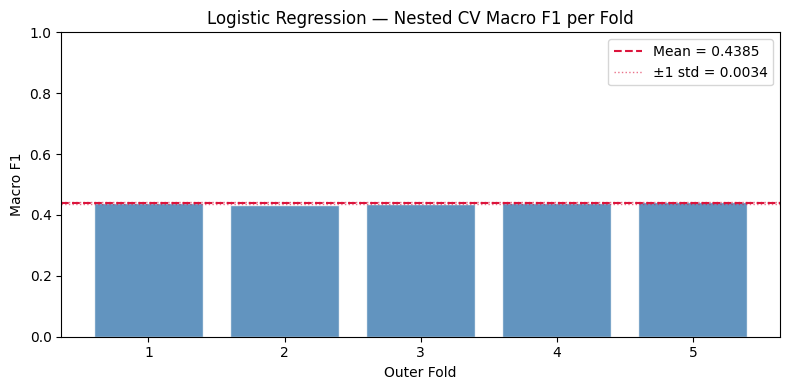

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
folds = list(range(1, 6))
ax.bar(folds, outer_scores, color='steelblue', edgecolor='white', alpha=0.85)
ax.axhline(np.mean(outer_scores), color='crimson', linestyle='--', linewidth=1.5,
           label=f'Mean = {np.mean(outer_scores):.4f}')
ax.axhline(np.mean(outer_scores) + np.std(outer_scores), color='crimson',
           linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(np.mean(outer_scores) - np.std(outer_scores), color='crimson',
           linestyle=':', linewidth=1, alpha=0.6,
           label=f'±1 std = {np.std(outer_scores):.4f}')
ax.set_xlabel('Outer Fold')
ax.set_ylabel('Macro F1')
ax.set_title('Logistic Regression — Nested CV Macro F1 per Fold')
ax.set_xticks(folds)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
print('Best hyperparameters across outer folds:')
param_counts = Counter([str(p) for p in best_params_log])
for params, count in param_counts.most_common():
    print(f'  {count:2d} fold(s): {params}')

Best hyperparameters across outer folds:
   3 fold(s): {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
   1 fold(s): {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
   1 fold(s): {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


## Final Model

Re-run `GridSearchCV` on the **full training set** to select the best hyperparameters, then evaluate on the held-out test set **once**.

In [7]:
print('Fitting final model on full training set...\n')

final_gs = GridSearchCV(
    LogisticRegression(
        class_weight='balanced', random_state=RANDOM_STATE, max_iter=2000
    ),
    param_grid,
    cv=inner_cv, scoring='f1_macro',
    n_jobs=-1, refit=True
)
final_gs.fit(X_train, y_train)

print(f'Best params      : {final_gs.best_params_}')
print(f'Best inner CV F1 : {final_gs.best_score_:.4f}')

Fitting final model on full training set...

Best params      : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best inner CV F1 : 0.4381


## Test Set Evaluation

> Evaluate on `test_multiclass.csv` **once only** — this is the final performance number.

In [8]:
final_model = final_gs.best_estimator_
y_pred_test = final_model.predict(X_test)

test_macro_f1 = f1_score(y_test, y_pred_test, average='macro')
print(f'Test set Macro F1 : {test_macro_f1:.4f}\n')
print('Classification Report (Test Set):')
print(classification_report(y_test, y_pred_test, labels=CLASS_ORDER, target_names=CLASS_ORDER))

Test set Macro F1 : 0.4355

Classification Report (Test Set):
              precision    recall  f1-score   support

        Good       0.80      0.63      0.70      7168
       Mixed       0.37      0.29      0.33      3208
         Bad       0.18      0.60      0.28       955

    accuracy                           0.53     11331
   macro avg       0.45      0.51      0.44     11331
weighted avg       0.63      0.53      0.56     11331



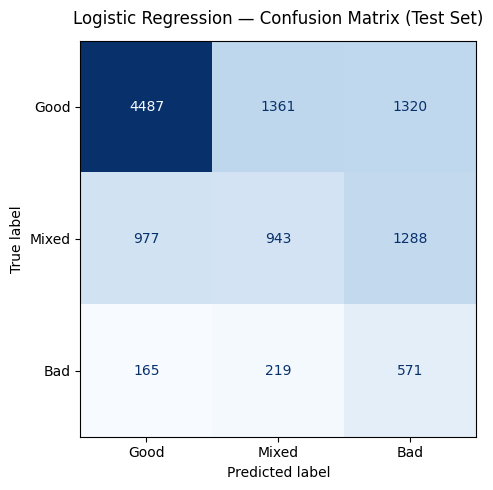

In [9]:
cm = confusion_matrix(y_test, y_pred_test, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix (Test Set)', pad=12)
plt.tight_layout()
plt.show()

## Feature Importance

Logistic Regression (One-vs-Rest) produces one coefficient per feature per class.  
Larger absolute value = stronger influence on that class prediction.

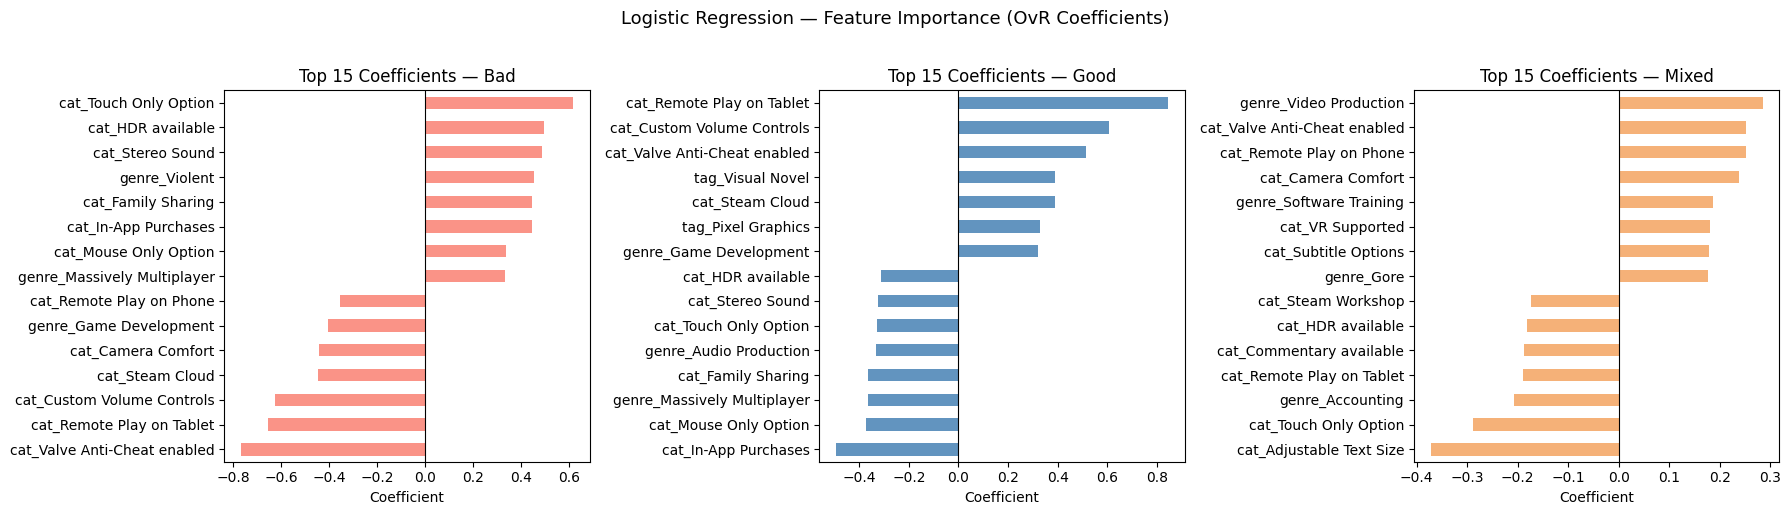

In [10]:
feature_names = X_train.columns.tolist()
coef = final_model.coef_   # shape: (n_classes, n_features)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, cls in enumerate(final_model.classes_):
    color = CLASS_COLORS[cls]
    coef_series = pd.Series(coef[i], index=feature_names)
    top_idx = coef_series.abs().nlargest(15).index
    coef_series[top_idx].sort_values().plot(
        kind='barh', ax=axes[i], color=color, alpha=0.85
    )
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'Top 15 Coefficients — {cls}')
    axes[i].set_xlabel('Coefficient')

plt.suptitle('Logistic Regression — Feature Importance (OvR Coefficients)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Results Summary

| Metric | Value |
|--------|-------|
| Nested CV Macro F1 (mean ± std) | **0.4385 ± 0.0034** |
| Test set Macro F1 | **0.4355** |
| Best params | C=0.1, L2, lbfgs |

**Per-class F1 (test set):**

| Class | Precision | Recall | F1 |
|-------|-----------|--------|----|
| Good  | 0.80 | 0.63 | 0.70 |
| Mixed | 0.37 | 0.29 | 0.33 |
| Bad   | 0.18 | 0.60 | 0.28 |

**Interpretation:**
- The model is decent at identifying **Good** games (F1=0.70) — they dominate the training data so the signal is strong
- **Mixed** and **Bad** are much harder — the model struggles to separate them from Good
- The CV estimate (0.4385) and test score (0.4355) are very close — no overfitting
- Macro F1 of **0.4355 is the baseline** — all other models (SVM, RF, XGBoost, KNN) must beat this